In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("archive/Housing.csv")

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [6]:
#checking the dataset
print("Null: ",df.isna().sum())
print("Duplicated count: ",df.duplicated().sum())

Null:  price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicated count:  0


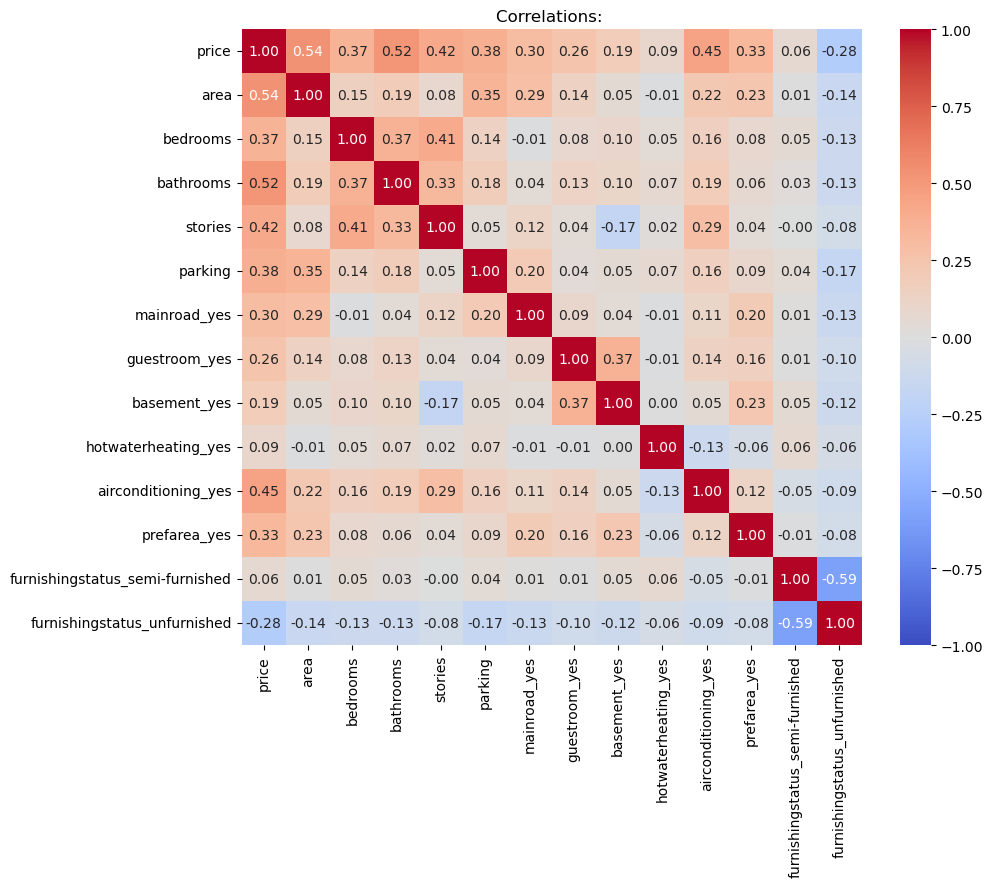

In [17]:
#to check which columns relate to price, so we dont waste time on uselesss features
df = pd.get_dummies(df, drop_first=True)
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot= True, 
            cmap="coolwarm",
            fmt=".2f", 
            vmin=-1,
              vmax=1)
plt.title("Correlations: ")
plt.show()





Spliting the data before training

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["price"])#everything except the target
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42 #20% is used for testing, 
                        #and random state ensures that the data is randomly split the same way
)

print("Train rows:", X_train.shape[0], " Test rows:", X_test.shape[0])


Train rows: 436  Test rows: 109


Training the data

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Learned Coefficient:")
for name,coef in zip(X.columns, model.coef_):
    print(f"{name:16s} : {coef:+.3f}")

print(f"{"Intercept(b)":16s}: {model.intercept_:+.3f}")

Learned Coefficient:
area             : +235.969
bedrooms         : +76778.702
bathrooms        : +1094444.786
stories          : +407476.595
parking          : +224841.913
mainroad_yes     : +367919.948
guestroom_yes    : +231610.037
basement_yes     : +390251.176
hotwaterheating_yes : +684649.885
airconditioning_yes : +791426.736
prefarea_yes     : +629890.565
furnishingstatus_semi-furnished : -126881.818
furnishingstatus_unfurnished : -413645.062
Intercept(b)    : +260032.358


Predicting

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_predict = model.predict(X_test)#by using the already trained model, we predict the prices of the testing
                                #and then store it in the variable

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_predict)

print(f"MAE  = ${mae:,.2f}")
print(f"MSE  = ${mse:,.2f}")
print(f"RMSE = ${rmse:,.2f}")
print(f"R^2  = {r2:.4f}")

MAE  = $970,043.40
MSE  = $1,754,318,687,330.66
RMSE = $1,324,506.96
R^2  = 0.6529


Evaluation



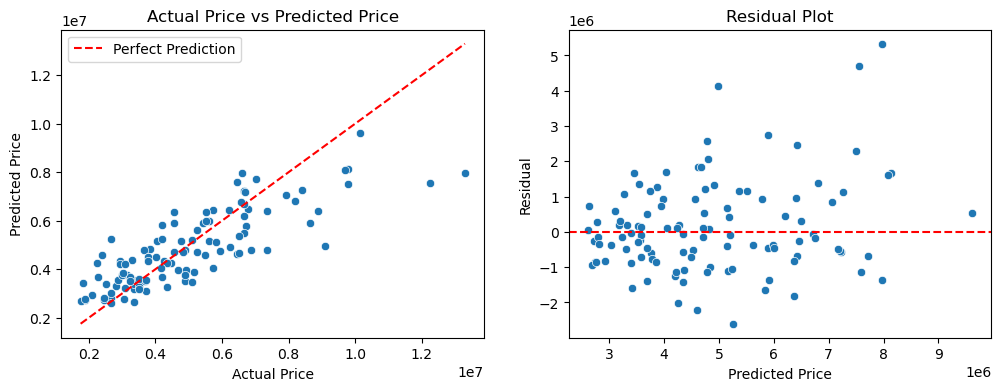

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=y_test, y=y_predict, ax=axes[0])
lims = [min(y_test.min(), y_predict.min()), max(y_test.max(), y_predict.max())]
axes[0].plot(lims, lims, "r--", label="Perfect Prediction")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Actual Price vs Predicted Price")
axes[0].legend()

residuals = y_test - y_predict
sns.scatterplot(x=y_predict, y=residuals, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual Plot")

plt.show()